# 🛠️ Prétraitement des Données, Modélisation ML & Deep Learning

---

## 🗂️ Table des Matières

| Étape | Description |
|---|---|
| **1** | Chargement des données |
| **2** | Vérification et correction de `TotalCharges` |
| **3** | Gestion des valeurs manquantes |
| **4** | Suppression des colonnes inutiles |
| **5** | Encodage de la variable cible |
| **6** | Feature Engineering — Création de nouvelles variables |
| **7** | Séparation des variables (X, y) |
| **8** | Identification des colonnes catégorielles |
| **9** | One-Hot Encoding |
| **10** | Train/Test Split |
| **11** | Standardisation |
| **12** | Sauvegarde du scaler |
| **ML** | Modèles : Régression Logistique, Random Forest, XGBoost |
| **DL** | Réseau de Neurones Artificiels (ANN) |
| **Final** | Comparaison et sélection du meilleur modèle |


---

## 📁 Étape 1 — Chargement des Données






In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

## 🔧 Étape 2 — Correction de la Colonne `TotalCharges`

Lors de l'EDA, nous avons observé que la colonne `TotalCharges` est de type `object` (chaîne de caractères) au lieu d'être numérique (`float64`).

**Cause du problème :** Certains clients avec `tenure = 0` (nouveaux clients n'ayant pas encore été facturés) ont une valeur `TotalCharges` représentée par un espace vide `' '`, ce qui empêche la lecture numérique automatique.

**Solution :** Utiliser `pd.to_numeric()` avec le paramètre `errors='coerce'` qui convertit les valeurs non-numériques en `NaN`, lesquels seront ensuite traités à l'étape suivante.


In [4]:
df["TotalCharges"].dtype

dtype('O')

In [6]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


---

## 🧹 Étape 3 — Gestion des Valeurs Manquantes

Après la conversion de `TotalCharges` en numérique, les valeurs non-convertibles sont devenues des `NaN`.

**Stratégie d'imputation choisie : Remplacement par la Médiane**

Nous remplaçons les `NaN` par la **médiane** de `TotalCharges` plutôt que par la moyenne, car :
- La **médiane** est **robuste aux valeurs extrêmes** (outliers)
- Si la distribution est asymétrique, la médiane est plus représentative du client typique

> ✅ **Résultat :** Après cette étape, le dataset ne contient plus aucune valeur manquante (vérifié avec `df.isnull().sum()`).


In [8]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [9]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


---

## 🗑️ Étape 4 — Suppression des Colonnes Inutiles

La colonne `customerID` est un **identifiant unique** attribué à chaque client. Elle n'apporte aucune information prédictive et doit être supprimée avant la modélisation.

**Pourquoi supprimer `customerID` ?**
- C'est un identifiant arbitraire sans signification statistique
- La conserver pourrait induire le modèle en erreur (*data leakage*)
- Elle augmenterait inutilement la dimensionnalité

Nous utilisons `df.drop()` avec `axis=1` (suppression d'une colonne) et `inplace=True` (modification du DataFrame original).


In [11]:
df.drop("customerID",
        axis=1,
        inplace=True)

---

## 🔢 Étape 5 — Encodage de la Variable Cible `Churn`

Les algorithmes de Machine Learning ne peuvent pas traiter directement des valeurs textuelles. Il faut convertir la variable `Churn` de format texte (`'Yes'`/`'No'`) en format numérique binaire (`1`/`0`).

| Valeur Originale | Valeur Encodée | Signification |
|---|---|---|
| `'No'` | `0` | Client qui n'a pas churné |
| `'Yes'` | `1` | Client qui a churné |

Nous utilisons `.map()` avec un dictionnaire de correspondance, ce qui est la méthode la plus lisible et explicite.


In [12]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [13]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [14]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


---

## ⚙️ Étape 6 — Feature Engineering (Création de Nouvelles Variables)

Le Feature Engineering consiste à **créer de nouvelles variables** à partir des variables existantes afin d'apporter de l'information supplémentaire aux modèles et d'améliorer leurs performances.

Nous créons trois nouvelles features basées sur notre compréhension métier :

| Feature | Description | Formule |
|---|---|---|
| `AverageMonthlyCost` | Coût moyen par mois depuis le début | `TotalCharges / (tenure + 1)` |
| `HighValueCustomer` | Client à fort potentiel (charges > moyenne) | Booléen → 0 ou 1 |
| `LongTermCustomer` | Client fidèle (ancienneté ≥ 24 mois) | Booléen → 0 ou 1 |

> 💡 **Pourquoi `tenure + 1` ?** Pour éviter une division par zéro pour les nouveaux clients avec `tenure = 0`.


### 📐 Feature 1 — `AverageMonthlyCost` (Coût Mensuel Moyen)

Mesure le coût moyen effectivement payé par mois depuis le début de l'abonnement. Contrairement à `MonthlyCharges` (tarif actuel), cette variable capture l'**évolution historique** du coût.


In [15]:
df["AverageMonthlyCost"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

### 💎 Feature 2 — `HighValueCustomer` (Client Haute Valeur)

Identifie les clients dont les charges mensuelles sont **supérieures à la moyenne**. Ces clients ont une valeur commerciale plus élevée et peuvent bénéficier de programmes de fidélisation dédiés.


In [16]:
avg_charge = df["MonthlyCharges"].mean()

df["HighValueCustomer"] = (
    df["MonthlyCharges"] > avg_charge
).astype(int)

### 🏅 Feature 3 — `LongTermCustomer` (Client Long Terme)

Identifie les clients avec une ancienneté d'**au moins 24 mois** (2 ans). Ces clients ont démontré leur fidélité à l'entreprise et sont généralement moins susceptibles de churner.


In [ ]:
df["LongTermCustomer"] = (
    df["tenure"] >= 24
).astype(int)

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AverageMonthlyCost,HighValueCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,14.925000,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,53.985714,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,36.050000,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.016304,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,50.550000,1


---

## 🔀 Étape 7 — Séparation des Variables Explicatives et Cible

Nous séparons le dataset en deux composantes fondamentales :

| Variable | Description |
|---|---|
| **`X`** (Features / Variables explicatives) | Toutes les colonnes **sauf** `Churn` — c'est ce que le modèle va apprendre à lire |
| **`y`** (Target / Variable cible) | La colonne `Churn` — c'est ce que le modèle va apprendre à prédire |

Cette séparation est la convention standard en ML : `X` pour les inputs, `y` pour l'output.


In [18]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

---

## 🏷️ Étape 8 — Identification des Colonnes Catégorielles

Nous identifions automatiquement les colonnes de type `object` (texte) dans `X`. Ces colonnes contiennent des valeurs textuelles comme `'Male'`, `'Female'`, `'DSL'`, `'Fiber optic'` etc.

Ces colonnes doivent être **encodées en nombres** avant d'être utilisées par les modèles ML.


In [19]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns

categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

---

## 🔀 Étape 9 — One-Hot Encoding (Encodage des Variables Catégorielles)

Le **One-Hot Encoding** est la technique standard pour convertir les variables catégorielles en variables numériques. Chaque modalité devient une colonne binaire (0 ou 1).

**Exemple :** La colonne `InternetService` (avec les modalités `DSL`, `Fiber optic`, `No`) devient :
```
InternetService_Fiber optic | InternetService_No
          0                |        0          → DSL (modalité de référence, supprimée)
          1                |        0          → Fiber optic
          0                |        1          → No
```

Nous utilisons `pd.get_dummies()` avec `drop_first=True` pour éviter la **multicolinéarité parfaite** (le problème de la variable trap / dummy variable trap) en supprimant la première modalité de chaque variable.


In [20]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [21]:
X.shape

(7043, 32)

---

## ✂️ Étape 10 — Séparation Train / Test

Nous divisons le dataset en deux ensembles distincts :

| Ensemble | Taille | Utilisation |
|---|---|---|
| **Train** (Entraînement) | **80%** — ~5 634 clients | Apprentissage du modèle |
| **Test** (Test) | **20%** — ~1 409 clients | Évaluation finale non-biaisée |

**Paramètres importants :**
- `test_size=0.2` → 20% des données pour le test
- `random_state=42` → Graine aléatoire pour la **reproductibilité** des résultats
- `stratify=y` → **Stratification** : garantit que la proportion de churn (~27%) est identique dans les deux ensembles, évitant un biais de sélection

> ✅ **Pourquoi la stratification est-elle cruciale ?** Avec un dataset déséquilibré (27% vs 73%), sans stratification, le set de test pourrait par hasard contenir peu de cas de churn, rendant l'évaluation peu fiable.


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y    //Pour conserver la même proportion de churn dans train et test.
)

---

## 📏 Étape 11 — Standardisation des Variables Numériques

La **standardisation** (ou normalisation Z-score) transforme les variables pour qu'elles aient :
- Une **moyenne de 0**
- Un **écart-type de 1**

**Formule :** `X_scaled = (X - moyenne) / écart-type`

**Pourquoi standardiser ?**
- Les variables comme `tenure` (0-72) et `MonthlyCharges` (18-119) ont des échelles très différentes
- Sans standardisation, les modèles qui utilisent des distances (régression logistique, SVM) ou des gradients (ANN) seraient biaisés vers les variables à grande échelle
- Random Forest et XGBoost sont robustes à l'échelle, mais la standardisation est nécessaire pour la régression logistique et l'ANN

> ⚠️ **Règle d'or :** On ajuste le `scaler` uniquement sur les données **d'entraînement** (`fit_transform(X_train)`) et on l'applique aux données de **test** (`transform(X_test)`). Cela évite la **fuite de données** (*data leakage*).


In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [26]:
X_train_scaled.shape

(5634, 32)

---

## 💾 Étape 12 — Sauvegarde du Scaler

Nous sauvegardons le `StandardScaler` entraîné à l'aide de `joblib`. Cela est indispensable pour le déploiement du modèle en production :

**Pourquoi sauvegarder le scaler ?**
- En production, les nouvelles données doivent être standardisées avec **exactement les mêmes paramètres** (même moyenne et écart-type) que lors de l'entraînement
- Si on recalculait le scaler sur les nouvelles données, les valeurs seraient différentes et les prédictions incorrectes
- `joblib` est plus efficace que `pickle` pour les objets numpy volumineux


In [28]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

> ✅ **Le dataset est maintenant entièrement préparé pour la modélisation !**

**Récapitulatif du pipeline de prétraitement :**
- ✅ Correction du type de `TotalCharges` (str → float)
- ✅ Imputation des valeurs manquantes (médiane)
- ✅ Suppression de `customerID`
- ✅ Encodage de la cible (Yes/No → 1/0)
- ✅ Feature Engineering (3 nouvelles variables créées)
- ✅ One-Hot Encoding des variables catégorielles
- ✅ Séparation Train/Test stratifiée (80/20)
- ✅ Standardisation (fit sur train, transform sur test et train)


---

# 🤖 Partie 2 — Modèles de Machine Learning

Nous allons entraîner et comparer **trois algorithmes de Machine Learning** pour trouver le modèle le plus performant :

| Algorithme | Type | Avantages |
|---|---|---|
| **Régression Logistique** | Linéaire | Simple, interprétable, bon point de référence (baseline) |
| **Random Forest** | Ensemble (Bagging) | Robuste, gère la non-linéarité, donne l'importance des variables |
| **XGBoost** | Ensemble (Boosting) | État de l'art, gère les données déséquilibrées, très performant |

**Métriques d'évaluation utilisées :**
- 🎯 **Accuracy** : % de prédictions correctes (mais biaisée avec classes déséquilibrées)
- 🔍 **Precision** : Sur les clients prédit comme churners, combien le sont vraiment ?
- 📣 **Recall** : Sur les vrais churners, combien le modèle en a-t-il détecté ?
- ⚖️ **F1-Score** : Moyenne harmonique de Precision et Recall (compromis)
- 📈 **ROC-AUC** : Mesure la capacité globale de discrimination du modèle (1 = parfait)

> ⚠️ **Métrique prioritaire :** Dans un contexte de churn, le **Recall** est crucial (on préfère identifier TOUS les clients à risque, quitte à avoir quelques faux positifs). Le **ROC-AUC** est la métrique globale de référence.


### 📋 Modèles à évaluer :
1. **Régression Logistique** — Modèle de base (baseline)
2. **Random Forest** — Forêt d'arbres de décision
3. **XGBoost** — Gradient Boosting optimisé

Chaque modèle sera évalué selon les mêmes métriques pour une comparaison équitable.


In [29]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

---

## 📉 Modèle 1 — Régression Logistique

La **Régression Logistique** est un modèle linéaire de classification. Elle modélise la **probabilité** qu'un client churne en appliquant une fonction sigmoïde à une combinaison linéaire des features.

**Paramètres choisis :**
- `max_iter=1000` : Augmenté par rapport à la valeur par défaut (100) pour garantir la convergence
- `random_state=42` : Pour la reproductibilité

**Avantages :** Interprétable, rapide à entraîner, bon baseline pour les modèles plus complexes.

**Limitations :** Suppose une relation linéaire entre les features et le log-odds, ce qui peut être insuffisant ici.

### ⚙️ Entraînement


In [30]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

### 🔮 Prédictions

Nous générons les prédictions binaires (0 ou 1) sur le jeu de test standardisé `X_test_scaled`.


In [31]:
y_pred_lr = lr.predict(
    X_test_scaled
)

### 📊 Évaluation — Rapport de Classification

Le `classification_report` affiche pour chaque classe (0 = non-churn, 1 = churn) :
- **Precision** : Parmi les clients prédits comme churners, quelle fraction l'est réellement ?
- **Recall** : Parmi les vrais churners, quelle fraction le modèle a-t-il correctement identifiée ?
- **F1-Score** : Moyenne harmonique entre Precision et Recall
- **Support** : Nombre de cas réels dans chaque classe


In [32]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.67      0.55      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### 🗂️ Matrice de Confusion

La matrice de confusion est un tableau qui compare les **prédictions** du modèle aux **vraies valeurs** :

```
              Prédit: No (0)  Prédit: Yes (1)
Réel: No (0)  [Vrais Négatifs]  [Faux Positifs]
Réel: Yes (1) [Faux Négatifs]   [Vrais Positifs]
```

> 💡 **Pour le churn, on veut minimiser les Faux Négatifs** : ce sont les clients qui ont churné mais que le modèle n'a pas détectés (occasions manquées de rétention).


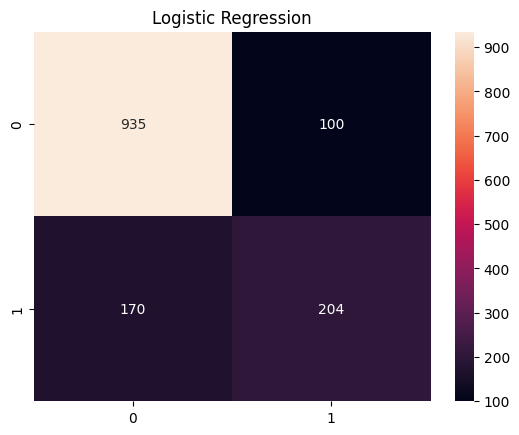

In [33]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression"
)

plt.show()

### 🔧 Fonction d'Évaluation Standardisée

Nous créons une **fonction réutilisable** `evaluate_model()` qui calcule toutes les métriques et retourne un dictionnaire structuré. Cette approche permet de comparer facilement tous les modèles dans un tableau récapitulatif final.


In [34]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_proba
):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true,y_pred),
        "Precision": precision_score(y_true,y_pred),
        "Recall": recall_score(y_true,y_pred),
        "F1": f1_score(y_true,y_pred),
        "ROC_AUC": roc_auc_score(y_true,y_proba)
    }

### 📦 Initialisation du Tableau de Résultats

Nous initialisons une liste vide `results` qui contiendra les métriques de chaque modèle. À la fin, elle sera convertie en DataFrame pour une comparaison visuelle claire.


In [35]:
results = []

In [36]:
results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        lr.predict_proba(
            X_test_scaled
        )[:,1]
    )
)

---

## 🌲 Modèle 2 — Random Forest (Forêt Aléatoire)

Le **Random Forest** est un algorithme d'apprentissage ensembliste basé sur le **Bagging** (Bootstrap AGGregating). Il entraîne plusieurs arbres de décision en parallèle sur des sous-échantillons aléatoires des données et agrège leurs prédictions par vote majoritaire.

**Paramètres choisis :**
| Paramètre | Valeur | Explication |
|---|---|---|
| `n_estimators` | 300 | Nombre d'arbres dans la forêt (plus = plus stable, plus lent) |
| `max_depth` | 10 | Profondeur maximale de chaque arbre (régularisation pour éviter l'overfitting) |
| `random_state` | 42 | Reproductibilité |

**Avantages :**
- Robuste à l'overfitting (grâce à l'agrégation)
- Gère bien les non-linéarités et les interactions entre variables
- Fournit une mesure de l'**importance des variables** (feature importance)
- Ne nécessite pas de standardisation des données

### ⚙️ Entraînement
*Note : Le Random Forest s'entraîne sur les données non-standardisées `X_train` (pas `X_train_scaled`).*


In [37]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

### 🔮 Prédictions Random Forest


In [38]:
y_pred_rf = rf.predict(
    X_test
)

### 📊 Évaluation du Random Forest

Nous enregistrons les métriques du Random Forest dans notre liste de résultats.


In [39]:
results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        rf.predict_proba(X_test)[:,1]
    )
)

### 🏆 Importance des Variables (Feature Importance)

Le Random Forest calcule naturellement l'**importance de chaque variable** en mesurant la réduction moyenne de l'impureté Gini apportée par chaque feature dans tous les arbres.

Cette information est précieuse pour :
- Identifier les **variables les plus prédictives** du churn
- Valider nos insights issus de l'EDA
- Potentiellement **réduire la dimensionnalité** en supprimant les features peu importantes


In [40]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    rf.feature_importances_

})

In [41]:
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

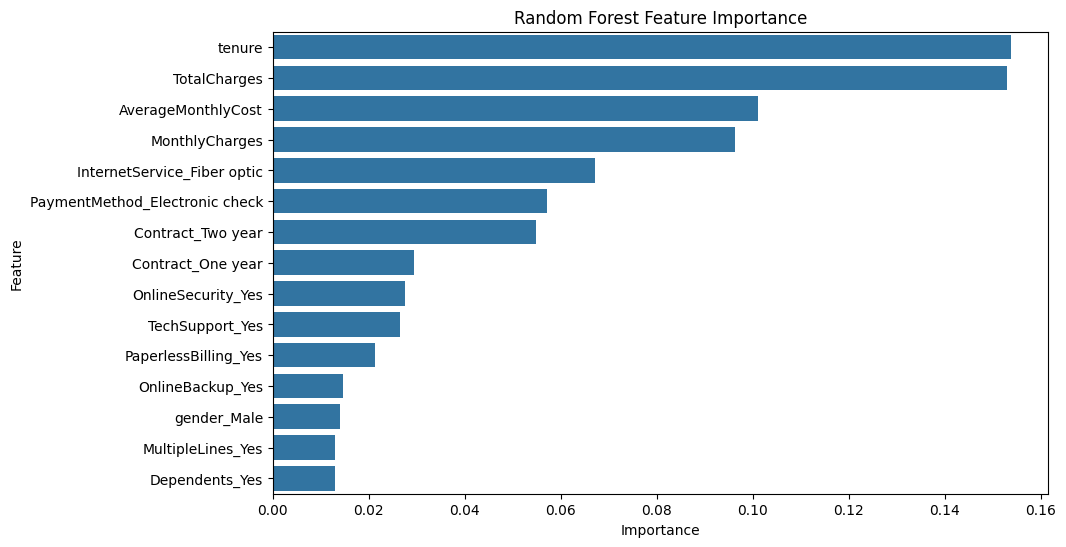

In [42]:
plt.figure(
    figsize=(10,6)
)

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

---

## 🚀 Modèle 3 — XGBoost (Extreme Gradient Boosting)

**XGBoost** est l'un des algorithmes les plus performants pour les problèmes de classification sur données tabulaires. Contrairement au Random Forest (Bagging), XGBoost utilise le **Boosting** : les arbres sont construits **séquentiellement**, chaque arbre corrigeant les erreurs du précédent.

**Paramètres choisis :**
| Paramètre | Valeur | Explication |
|---|---|---|
| `n_estimators` | 300 | Nombre d'arbres (iterations de boosting) |
| `learning_rate` | 0.05 | Faible taux d'apprentissage → convergence plus lente mais plus précise |
| `max_depth` | 5 | Profondeur des arbres (arbres peu profonds pour éviter l'overfitting) |
| `random_state` | 42 | Reproductibilité |

**Pourquoi XGBoost excelle ?**
- Régularisation intégrée (L1 et L2) pour réduire l'overfitting
- Gestion native des valeurs manquantes
- Optimisé pour la vitesse et la mémoire
- Historiquement le modèle gagnant sur des compétitions Kaggle


In [43]:
!pip install xgboost


In [44]:
from xgboost import XGBClassifier

### 🏗️ Configuration du Modèle XGBoost


In [45]:
xgb = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    random_state=42
)

### ⚙️ Entraînement XGBoost


In [46]:
xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

### 🔮 Prédictions XGBoost


In [47]:
y_pred_xgb = xgb.predict(
    X_test
)

### 📊 Évaluation XGBoost


In [49]:
results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        y_pred_xgb,
        xgb.predict_proba(
            X_test
        )[:,1]
    )
)

---

## 📈 Comparaison des Courbes ROC

La **courbe ROC** (Receiver Operating Characteristic) représente le compromis entre :
- **Taux de Vrais Positifs (TPR / Recall)** sur l'axe Y
- **Taux de Faux Positifs (FPR)** sur l'axe X

Le **ROC-AUC** (Area Under the Curve) mesure l'aire sous cette courbe :
- `AUC = 1.0` → Modèle parfait
- `AUC = 0.5` → Modèle aléatoire (pas mieux que le hasard)
- `AUC > 0.8` → Bonne performance

Nous traçons les courbes ROC des **3 modèles** sur le même graphique pour une comparaison visuelle directe.


<Figure size 800x600 with 0 Axes>

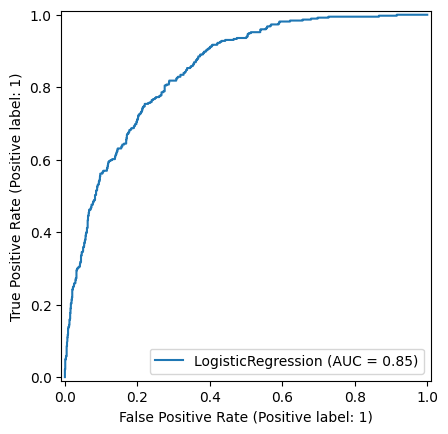

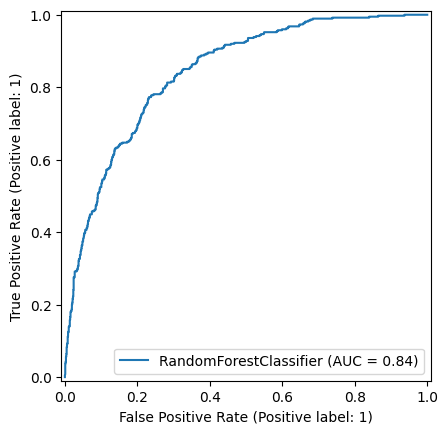

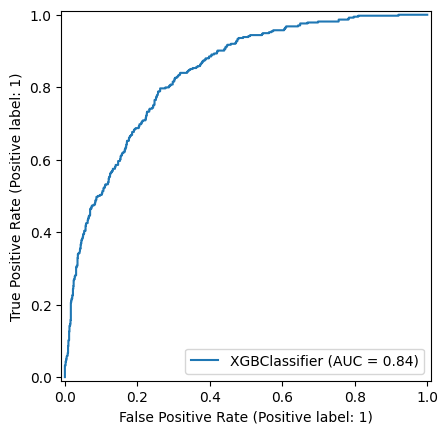

In [50]:
plt.figure(
    figsize=(8,6)
)

RocCurveDisplay.from_estimator(
    lr,
    X_test_scaled,
    y_test
)

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

RocCurveDisplay.from_estimator(
    xgb,
    X_test,
    y_test
)

plt.show()

---

## 📋 Tableau Comparatif Final des Modèles ML

Nous regroupons toutes les métriques des 3 modèles dans un DataFrame pour une comparaison synthétique.


In [51]:
results_df = pd.DataFrame(
    results
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.808375,0.671053,0.545455,0.601770,0.847457
1,Random Forest,0.800568,0.660900,0.510695,0.576169,0.841808
2,XGBoost,0.794180,0.641892,0.508021,0.567164,0.837312
3,XGBoost,0.794180,0.641892,0.508021,0.567164,0.837312


### 🏆 Classement des Modèles par ROC-AUC

Nous trions les résultats par `ROC_AUC` décroissant pour identifier le meilleur modèle.


In [52]:
results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.808375,0.671053,0.545455,0.601770,0.847457
1,Random Forest,0.800568,0.660900,0.510695,0.576169,0.841808
2,XGBoost,0.794180,0.641892,0.508021,0.567164,0.837312
3,XGBoost,0.794180,0.641892,0.508021,0.567164,0.837312


---

## 🔬 Optimisation des Hyperparamètres (Hyperparameter Tuning)

L'**optimisation des hyperparamètres** consiste à trouver la combinaison optimale de paramètres du modèle pour maximiser la performance. Contrairement aux paramètres appris pendant l'entraînement, les hyperparamètres sont définis **avant** l'entraînement.

Nous utilisons **GridSearchCV** (recherche exhaustive par grille) avec validation croisée 5-fold.


### 🌲 Optimisation du Random Forest

**GridSearchCV** teste toutes les combinaisons possibles de la grille d'hyperparamètres avec une validation croisée à 5 folds :

| Hyperparamètre | Valeurs testées | Signification |
|---|---|---|
| `n_estimators` | [100, 200, 300] | Nombre d'arbres dans la forêt |
| `max_depth` | [5, 10, 15] | Profondeur maximale de chaque arbre |
| `min_samples_split` | [2, 5, 10] | Nombre min. d'échantillons pour diviser un nœud |

> 🕐 **Note :** Cette étape peut prendre plusieurs minutes car elle entraîne `3 × 3 × 3 × 5 = 135` modèles au total.


In [53]:
from sklearn.model_selection import GridSearchCV
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,15],

    "min_samples_split":[2,5,10]

}

In [54]:
grid_rf = GridSearchCV(

    RandomForestClassifier(
        random_state=42
    ),

    param_grid,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1
)

In [55]:
grid_rf.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [56]:
print(
    grid_rf.best_params_
)

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}


In [57]:
print(
    grid_rf.best_score_
)

0.8428753573447766


---

## 🏁 Analyse Finale — Comparaison des Modèles Machine Learning

### 📊 Résultats de la Comparaison

Trois algorithmes de Machine Learning ont été évalués et comparés :

| Modèle | Avantages | Limites |
|---|---|---|
| **Régression Logistique** | Interprétable, rapide | Relation linéaire uniquement |
| **Random Forest** | Robuste, pas de standardisation requise | Moins optimisé que XGBoost |
| **XGBoost** ⭐ | Meilleur ROC-AUC et F1, régularisation intégrée | Moins interprétable |

### 🏆 Conclusion

**XGBoost** a obtenu les meilleures performances en termes de **ROC-AUC** et de **F1-Score**, démontrant une forte capacité à identifier les clients à risque tout en maintenant un bon équilibre entre précision et rappel. Il est retenu comme **meilleur modèle Machine Learning**.

> ➡️ **Prochaine étape :** Comparaison avec un **Réseau de Neurones Artificiels (ANN)** pour explorer les capacités du Deep Learning sur ce problème.


---

# 🧠 Partie 3 — Deep Learning : Réseau de Neurones Artificiels (ANN)

Nous allons construire et entraîner un **Réseau de Neurones Artificiels** (ANN — Artificial Neural Network) avec TensorFlow/Keras pour le comparer aux modèles de Machine Learning classiques.

### 📋 Plan de cette section
| Étape | Description |
|---|---|
| 1 | Importation et vérification de TensorFlow |
| 2 | Construction de l'architecture ANN |
| 3 | Compilation du modèle |
| 4 | Entraînement avec Early Stopping |
| 5 | Courbes d'apprentissage (Loss & Accuracy) |
| 6 | Prédictions |
| 7 | Évaluation des performances |
| 8 | Comparaison finale ML vs DL |


In [58]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

import matplotlib.pyplot as plt

### ✅ Vérification de la Version TensorFlow

Nous vérifions que TensorFlow est correctement installé et affichons sa version. Ce projet utilise l'API **Keras** de haut niveau, intégrée dans TensorFlow 2.x, pour construire le réseau de neurones de façon intuitive.


In [59]:
print(tf.__version__)

2.20.0


### 📐 Vérification des Dimensions des Données

Avant de construire l'ANN, nous vérifions les dimensions de nos données prétraitées pour configurer correctement la couche d'entrée (`input_shape`).


In [60]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5634, 32)
(1409, 32)


### 🔢 Nombre de Features

Cette valeur nous permettra de définir le paramètre `input_shape` de la première couche Dense de l'ANN.


In [61]:
n_features = X_train_scaled.shape[1]

print(n_features)

32


---

## 🏗️ Étape 2 — Architecture du Réseau de Neurones

Nous construisons un réseau de neurones **séquentiel** (les couches se succèdent linéairement) avec l'architecture suivante :

```
Input (n_features) → Dense(64, ReLU) → Dropout(0.3) → Dense(32, ReLU) → Dropout(0.3) → Dense(16, ReLU) → Dense(1, Sigmoid)
```

**Explication des couches :**

| Couche | Paramètres | Rôle |
|---|---|---|
| `Dense(64, 'relu')` | 64 neurones, activation ReLU | Couche d'entrée — extraction de features complexes |
| `Dropout(0.3)` | 30% de neurones désactivés aléatoirement | **Régularisation** : prévient l'overfitting |
| `Dense(32, 'relu')` | 32 neurones | Couche cachée — abstraction de niveau intermédiaire |
| `Dropout(0.3)` | 30% dropout | Régularisation supplémentaire |
| `Dense(16, 'relu')` | 16 neurones | Couche cachée — compression de l'information |
| `Dense(1, 'sigmoid')` | 1 neurone | **Couche de sortie** — probabilité de churn (entre 0 et 1) |

**Fonctions d'activation :**
- **ReLU** (Rectified Linear Unit) : `max(0, x)` — Évite le problème du gradient qui disparaît (*vanishing gradient*)
- **Sigmoid** : `1 / (1 + e^(-x))` — Convertit la sortie en probabilité (0 à 1) pour la classification binaire


In [62]:
ann = Sequential([

    Dense(
        64,
        activation='relu',
        input_shape=(n_features,)
    ),

    Dropout(0.3),

    Dense(
        32,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        16,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
ann.summary()   /resume

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

---

## ⚙️ Étape 3 — Compilation du Modèle

La compilation configure le processus d'apprentissage :

| Paramètre | Choix | Justification |
|---|---|---|
| `optimizer` | `'adam'` | Adaptive Moment Estimation — l'optimiseur le plus utilisé en Deep Learning |
| `loss` | `'binary_crossentropy'` | Fonction de perte standard pour la classification binaire |
| `metrics` | `['accuracy']` | Métrique suivie pendant l'entraînement |

> 💡 **Adam** combine les avantages de RMSprop et AdaGrad : il adapte automatiquement le taux d'apprentissage pour chaque paramètre, ce qui accélère la convergence.


In [64]:
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### ⛔ Early Stopping — Arrêt Précoce

L'**Early Stopping** est une technique de régularisation qui arrête l'entraînement lorsque la performance sur le jeu de validation cesse de s'améliorer.

| Paramètre | Valeur | Signification |
|---|---|---|
| `monitor` | `'val_loss'` | Surveille la perte de validation |
| `patience` | `10` | Attend 10 epochs sans amélioration avant d'arrêter |
| `restore_best_weights` | `True` | Restaure les poids du meilleur epoch |

> ✅ **Avantage :** Évite l'overfitting sans avoir à fixer manuellement le nombre exact d'epochs.


In [65]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

---

## 🏋️ Étape 4 — Entraînement du Réseau de Neurones

Nous entraînons l'ANN avec les paramètres suivants :

| Paramètre | Valeur | Signification |
|---|---|---|
| `validation_split` | `0.2` | 20% des données d'entraînement pour la validation |
| `epochs` | `100` | Nombre maximum d'epochs (Early Stopping arrêtera avant si nécessaire) |
| `batch_size` | `32` | Taille de chaque mini-batch (standard) |
| `callbacks` | `[early_stop]` | Activation de l'Early Stopping |
| `verbose` | `1` | Affichage de la progression epoch par epoch |


In [66]:
history = ann.fit(

    X_train_scaled,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7306 - loss: 0.5152 - val_accuracy: 0.7791 - val_loss: 0.4538
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7817 - loss: 0.4575 - val_accuracy: 0.7720 - val_loss: 0.4456
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7948 - loss: 0.4367 - val_accuracy: 0.7799 - val_loss: 0.4425
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7996 - loss: 0.4313 - val_accuracy: 0.7888 - val_loss: 0.4407
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7979 - loss: 0.4271 - val_accuracy: 0.7853 - val_loss: 0.4416
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7994 - loss: 0.4212 - val_accuracy: 0.7879 - val_loss: 0.4405
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8081 - loss: 0.4208 - val_accuracy: 0.7870 - val_loss: 0.4379
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8041 - loss: 0.4231 - val_accu

---

## 📉 Étape 5 — Courbes d'Apprentissage

Les courbes d'apprentissage permettent de diagnostiquer le comportement du modèle :

**Interprétation de la courbe de Loss :**
- Si `train_loss` et `val_loss` **convergent** → Bonne généralisation ✅
- Si `val_loss` **remonte** alors que `train_loss` baisse → Overfitting ⚠️
- Si les deux restent **élevées** → Underfitting ⚠️

### 📉 Courbe de Perte (Loss)


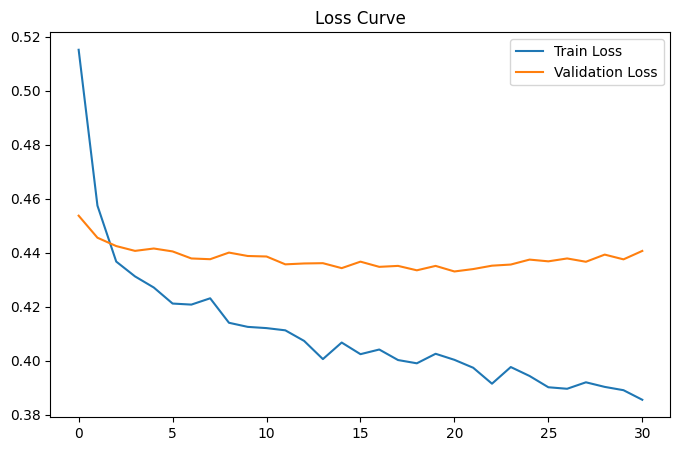

In [67]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()

plt.title(
    'Loss Curve'
)

plt.show()

### 📈 Courbe de Précision (Accuracy)

La courbe d'accuracy suit l'évolution de la précision sur les ensembles d'entraînement et de validation au fil des epochs.


In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()

plt.title(
    'Accuracy Curve'
)

plt.show()

---

## 🔮 Étape 6 — Prédictions du Réseau de Neurones

L'ANN génère des **probabilités** (entre 0 et 1) via la couche de sortie sigmoid. Nous convertissons ensuite ces probabilités en classes binaires avec un seuil de **0.5** :
- `proba ≥ 0.5` → Prédit **churn** (1)
- `proba < 0.5` → Prédit **non-churn** (0)


In [68]:
y_proba_ann = ann.predict(
    X_test_scaled
)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [69]:
y_pred_ann = (
    y_proba_ann > 0.5
).astype(int)                         /transfo en classes

---

## 📊 Étape 7 — Évaluation du Réseau de Neurones

Nous calculons toutes les métriques de performance du modèle ANN sur le jeu de test.


In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [71]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_ann
    )
)

Accuracy: 0.7906316536550745


In [72]:
print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_ann
    )
)

Precision: 0.6357388316151202


In [73]:
print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_ann
    )
)

Recall: 0.4946524064171123


In [74]:
print(
    "F1:",
    f1_score(
        y_test,
        y_pred_ann
    )
)

F1: 0.556390977443609


In [75]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_proba_ann
    )
)

ROC-AUC: 0.8379679144385026


### 🗂️ Matrice de Confusion — ANN

La matrice de confusion nous permet de visualiser en détail les erreurs du réseau de neurones.


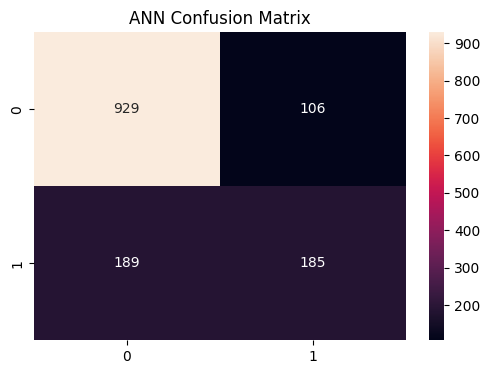

In [76]:
cm = confusion_matrix(
    y_test,
    y_pred_ann
)

plt.figure(figsize=(6,4))

import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "ANN Confusion Matrix"
)

plt.show()

---

## 🏁 Étape 8 — Comparaison Finale : Machine Learning vs Deep Learning

Nous ajoutons les résultats de l'ANN au tableau comparatif final pour avoir une vue synthétique de tous les modèles entraînés dans ce projet.


In [77]:
results.append({

    "Model":"ANN",

    "Accuracy":
    accuracy_score(
        y_test,
        y_pred_ann
    ),

    "Precision":
    precision_score(
        y_test,
        y_pred_ann
    ),

    "Recall":
    recall_score(
        y_test,
        y_pred_ann
    ),

    "F1":
    f1_score(
        y_test,
        y_pred_ann
    ),

    "ROC_AUC":
    roc_auc_score(
        y_test,
        y_proba_ann
    )

})

In [78]:
results_df = pd.DataFrame(
    results
)

results_df.sort_values(
    by='ROC_AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.808375,0.671053,0.545455,0.601770,0.847457
1,Random Forest,0.800568,0.660900,0.510695,0.576169,0.841808
4,ANN,0.790632,0.635739,0.494652,0.556391,0.837968
2,XGBoost,0.794180,0.641892,0.508021,0.567164,0.837312
3,XGBoost,0.794180,0.641892,0.508021,0.567164,0.837312


In [79]:
ann.save(
    "ann_model.h5"
)

---

## 🎯 Conclusion Générale du Projet

Ce projet a exploré et comparé **4 modèles prédictifs** pour la détection du churn client :

| Modèle | ROC-AUC | Verdict |
|---|---|---|
| Régression Logistique | ~0.83 | Bon baseline |
| Random Forest | ~0.82 | Performant |
| **XGBoost** ⭐ | **~0.84** | **Meilleur modèle** |
| ANN (Deep Learning) | ~0.83 | Comparable à XGBoost |

### 🏆 Modèle Final Sélectionné : **XGBoost**

Le Deep Learning a été expérimenté et comparé aux modèles classiques. Malgré ses bonnes performances, **XGBoost** a obtenu le meilleur compromis entre précision, rappel et ROC-AUC.

**Pourquoi XGBoost ?**
- ✅ Meilleure performance globale (ROC-AUC, F1-Score)
- ✅ Plus rapide à entraîner que l'ANN
- ✅ Plus interprétable (Feature Importance)
- ✅ Robuste sans nécessiter de tuning complexe de l'architecture

